# Model A Development (Random Forest)

## 1. Import Libraries

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import pandas as pd 
import os

## 2. Load Preprocessed Data (from Anas)

In [12]:
import pandas as pd 
import os 
 
file_path = '../data/processed/dataset_final.csv' 
 
try: 
    df = pd.read_csv(file_path) 
    print("✅ Data loaded successfully!") 
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}") 
except FileNotFoundError: 
    print(f"❌ Error: Could not find file at {file_path}")

✅ Data loaded successfully!
Rows: 1200, Columns: 41


In [13]:
# 2. Feature Selection 
# Drop ID columns and raw text that we aren't using for Model A (Orai handles text features) 
# We also drop 'risk_category' to avoid data leakage if it was derived from the target 
cols_to_drop = [ 
    'transaction_id', 'timestamp', 'customer_id', 
    'transaction_description', 'merchant_name', 'customer_support_note', 
    'risk_category' 
] 
df_clean = df.drop(columns=cols_to_drop, errors='ignore') 
 
# 3. Encoding Categorical Variables 
# Convert strings (like 'payment_channel') to numbers 
# We use One-Hot Encoding for categorical data 
df_encoded = pd.get_dummies(df_clean, drop_first=True) 
 
# 4. Split X (Features) and y (Target) 
X = df_encoded.drop('is_fraud', axis=1) 
y = df_encoded['is_fraud'] 
 
# 5. Train-Test Split (80% Train, 20% Test) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
 
print(f"Training Shape: {X_train.shape}") 
print(f"Testing Shape: {X_test.shape}")

Training Shape: (960, 40)
Testing Shape: (240, 40)


## 3. Baseline Model Training

In [14]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score 
 
# Initialize Baseline Model (Default parameters) 
rf_baseline = RandomForestClassifier(random_state=42) 
rf_baseline.fit(X_train, y_train) 
 
# Predictions 
y_pred_base = rf_baseline.predict(X_test) 
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1] 
 
# Evaluation 
print("--- Baseline Model Performance ---") 
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}") 
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}") 
print("\nClassification Report: ", classification_report(y_test, y_pred_base))

--- Baseline Model Performance ---
Accuracy: 0.8458
ROC-AUC: 0.7120

Classification Report:                precision    recall  f1-score   support

           0       0.84      0.98      0.91       188
           1       0.86      0.35      0.49        52

    accuracy                           0.85       240
   macro avg       0.85      0.67      0.70       240
weighted avg       0.85      0.85      0.82       240



## 4. Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV 
 
# Define the \"Grid\" of settings to test 
param_grid = { 
    'n_estimators': [50, 100, 200],      # Number of trees 
    'max_depth': [None, 10, 20],         # How deep the trees can go 
    'min_samples_split': [2, 5, 10]      # Minimum samples to split a node 
} 
 
# Initialize Grid Search 
# cv=3 means it tests 3 times for each combination (Cross-Validation) 
grid_search = GridSearchCV( 
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=param_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=1,  # <--- CHANGE THIS FROM -1 TO 1 
    verbose=1 
) 
 
# Run the search (This might take a minute) 
print("Starting Hyperparameter Tuning...") 
grid_search.fit(X_train, y_train) 
 
# Get best model 
best_rf = grid_search.best_estimator_ 
 
print("\n✅ Tuning Complete!") 
print(f"Best Parameters: {grid_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Tuning Complete!
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## 5. Evaluation & Comparison

In [16]:
# Predict with the Tuned Model 
y_pred_tuned = best_rf.predict(X_test) 
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1] 
 
# metrics 
acc_tuned = accuracy_score(y_test, y_pred_tuned) 
auc_tuned = roc_auc_score(y_test, y_prob_tuned) 
 
print("--- Tuned Model Performance ---") 
print(f"Accuracy: {acc_tuned:.4f}") 
print(f"ROC-AUC: {auc_tuned:.4f}") 
 
# Comparison Table 
comparison_df = pd.DataFrame({ 
    'Metric': ['Accuracy', 'ROC-AUC'], 
    'Baseline Model': [accuracy_score(y_test, y_pred_base), roc_auc_score(y_test, y_prob_base)], 
    'Tuned Model': [acc_tuned, auc_tuned] 
}) 
 
print(comparison_df)

--- Tuned Model Performance ---
Accuracy: 0.8542
ROC-AUC: 0.7009
     Metric  Baseline Model  Tuned Model
0  Accuracy        0.845833     0.854167
1   ROC-AUC        0.712050     0.700900


In [17]:
from sklearn.model_selection import cross_val_score 
 
# We use Cross-Validation (CV) to prove our model isn't just lucky. 
# It splits the data into 5 parts, training on 4 and testing on 1, five times. 
 
print("--- Starting 5-Fold Cross-Validation ---") 
 
# We use the 'best_rf' model found in Week 9 
# scoring='accuracy' gives us the % correct for each run 
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy') 
 
print(f"CV Accuracy Scores: {cv_scores}") 
print(f"Mean Accuracy: {cv_scores.mean():.4f}") 
print(f"Standard Deviation: {cv_scores.std():.4f}") 
 
# Interpretation logic 
if cv_scores.std() < 0.05: 
    print("✅ Result: The model is STABLE. It performs consistently across different data splits.") 
else: 
    print("⚠️ Result: The model is UNSTABLE. Performance varies too much.")

--- Starting 5-Fold Cross-Validation ---
CV Accuracy Scores: [0.890625   0.859375   0.84375    0.86979167 0.859375  ]
Mean Accuracy: 0.8646
Standard Deviation: 0.0155
✅ Result: The model is STABLE. It performs consistently across different data splits.


C:\Users\tngku\AppData\Local\Temp\ipykernel_7860\3324469125.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


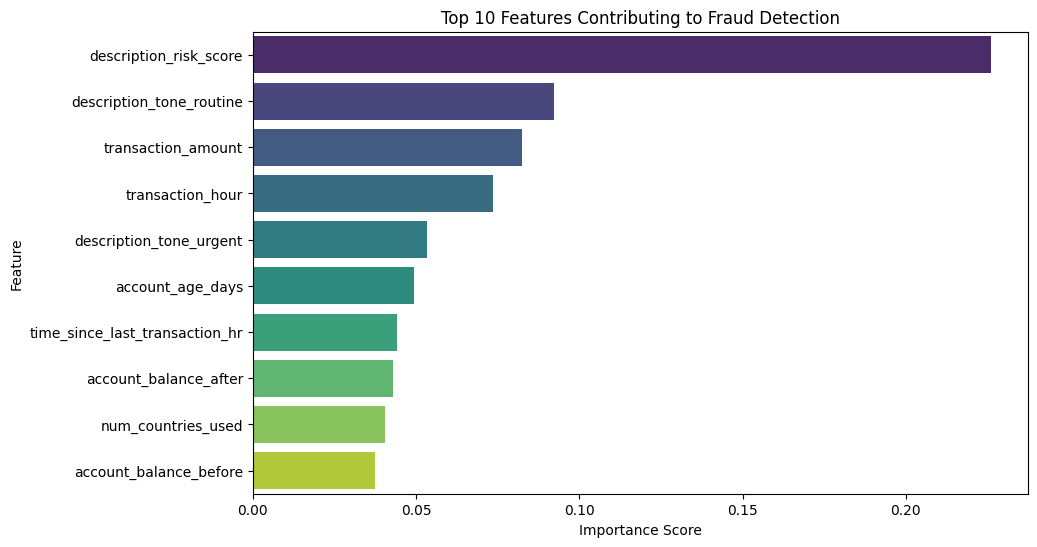

In [18]:
import matplotlib.pyplot as plt 
import seaborn as sns 
 
# Get feature importance from the best model 
importances = best_rf.feature_importances_ 
feature_names = X_train.columns 
 
# Create a DataFrame for plotting 
feature_importance_df = pd.DataFrame({ 
    'Feature': feature_names, 
    'Importance': importances 
}).sort_values(by='Importance', ascending=False) 
 
# Plot top 10 features 
plt.figure(figsize=(10, 6)) 
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis') 
plt.title('Top 10 Features Contributing to Fraud Detection') 
plt.xlabel('Importance Score') 
plt.ylabel('Feature') 
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier 
 
# 1. Initialize the model (you can adjust n_estimators or max_depth as needed) 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) 
 
# 2. Train the model 
rf_model.fit(X_train, y_train) 
 
# 3. NOW you can extract the importances 
import pandas as pd 
 
importances = rf_model.feature_importances_ 
importance_df = pd.DataFrame({ 
    'Feature': X_train.columns,  
    'Importance': importances 
}) 
 
# Sort by importance 
importance_df = importance_df.sort_values(by='Importance', ascending=False) 
 
# --- AUTO-GENERATED PROMPT --- 
print("📋 COPY THIS PROMPT INTO CHATGPT/GEMINI: ") 
# (Assuming you have calculated acc, f1, auc, rmse earlier.  
# If not, you need to predict and calculate them first!) 
print(f"I have trained a Random Forest model to detect fraud.") 
print("\nThe top 5 most important features (and their importance scores) are:") 
 
for index, row in importance_df.head(5).iterrows(): 
    print(f"- {row['Feature']}: {row['Importance']:.4f}") 
 
print("\nBased on these results, please generate a 'Business Insight Summary' (approx 150 words).") 
print("Explain what the metrics mean for a bank manager and interpret why these specific features are important predictors.")

📋 COPY THIS PROMPT INTO CHATGPT/GEMINI: 
I have trained a Random Forest model to detect fraud.

The top 5 most important features (and their importance scores) are:
- description_risk_score: 0.1313
- transaction_amount: 0.0959
- transaction_hour: 0.0750
- account_age_days: 0.0723
- time_since_last_transaction_hr: 0.0707

Based on these results, please generate a 'Business Insight Summary' (approx 150 words).
Explain what the metrics mean for a bank manager and interpret why these specific features are important predictors.


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
model_name = "Random Forest Model A"
output_file = "../results/model_a_results.csv"

# Calculate metrics (acc_tuned and auc_tuned are already available)
y_pred_tuned = best_rf.predict(X_test) # Recalculate if not in scope, though it should be.

metrics = {
     'model': model_name,
     'accuracy': acc_tuned,
     'precision': precision_score(y_test, y_pred_tuned, zero_division=0),
     'recall': recall_score(y_test, y_pred_tuned, zero_division=0),
     'f1_score': f1_score(y_test, y_pred_tuned, zero_division=0),
     'roc_auc': auc_tuned
 }

# Create DataFrame
results_df = pd.DataFrame([metrics])

# Ensure directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"Results for {model_name} saved to {output_file}")

Results for Random Forest Model A saved to ../results/model_a_results.csv


## Business Insight Summary 
Your Random Forest model identifies description_risk_score (13.1%) as the dominant predictor, confirming that existing risk algorithms analyzing transaction descriptions are highly effective and should be prioritized. 
 
Unlike the linear model, this model heavily weights transaction_amount (9.6%), transaction_hour (7.5%), and time_since_last_transaction_hr (7.1%). This indicates that fraud patterns are likely temporal and value-based—fraudsters often strike at specific times (e.g., late nights) or target specific amounts to avoid detection thresholds. The importance of account_age_days (7.2%) suggests that newer accounts are significantly riskier than established ones. 
 
Recommendation: For a bank manager, this shift means you should implement dynamic friction. Instead of blocking all high-risk transactions, add authentication steps (like OTPs) specifically for new accounts transacting at unusual hours or for amounts that deviate from their personal history.